In [1]:
import math
import random
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 20260908
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")  # force CPU for reproducibility

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.13.0+cu132
Device: cuda


# GAMEX Practical 2 — Conditional Normalising Flows for Edinburgh Airport Arrivals

**Edinburgh Summer School on Generative AI for Extremes — 8 September 2026**  
**Suggested time for this Notebook:** 30 minutes

This notebook models the **same synthetic Edinburgh Airport arrival trajectories** as the Transformer practical, but keeps every coordinate continuous.

We learn a conditional RealNVP map with runway direction supplied as context. The normalising flow achieves it through **invertibility and change of variables**.


## Learning goals

By the end you should be able to:

- represent an entire aircraft approach as one continuous multivariate vector;
- standardise using training-set statistics only;
- fit a conditional multivariate-Gaussian baseline;
- implement an affine coupling layer from scratch;
- condition coupling networks on Runway 06 versus Runway 24;
- calculate the exact log-Jacobian determinant;
- train by maximum likelihood;
- test numerical invertibility before and after training;
- inspect latent Gaussianisation;
- generate complete continuous Edinburgh arrivals;
- evaluate route geometry and smoothness.


## 1. Generate the same synthetic Edinburgh arrival trajectory


In [2]:
# -------------------------------------------------------------------
# Synthetic Edinburgh Airport arrival trajectory simulator
# -------------------------------------------------------------------
#
# Real context used:
#   * Edinburgh has one physical runway, 06/24.
#   * Runway 06 arrivals approach from the west / south-west.
#   * Runway 24 arrivals approach from the east / north-east.
#
# Teaching assumptions:
#   * We generate simplified radar-vectoring-like turns onto final.
#   * These are NOT real ADS-B tracks, STARs, ILS procedures or ATC clearances.
#   * The simulator is designed only to create a realistic looking
#     distribution for learning generative modelling.
#
# Local coordinate system:
#   x = East (km)
#   y = North (km)
#   airport/runway centre = (0, 0)

N_WAYPOINTS = 30
RUNWAY_LENGTH_KM = 2.56
HALF_RUNWAY_KM = RUNWAY_LENGTH_KM / 2

HEADING_06 = 60.0
HEADING_24 = 240.0

P_RUNWAY_24 = 0.85

AIRSPACE_XLIM = (-40.0, 40.0)
AIRSPACE_YLIM = (-30.0, 30.0)

def heading_vector(deg):
    rad = math.radians(deg)
    return torch.tensor(
        [math.sin(rad), math.cos(rad)],
        dtype=torch.float32,
    )

D06 = heading_vector(HEADING_06)
D24 = heading_vector(HEADING_24)

CROSS = torch.tensor([D06[1], -D06[0]])

THRESHOLD_06 = -HALF_RUNWAY_KM * D06
THRESHOLD_24 = +HALF_RUNWAY_KM * D06

def smoothstep(q):
    q = torch.clamp(q, 0.0, 1.0)
    return q * q * (3.0 - 2.0 * q)

def make_edinburgh_arrivals(
    n_flights=4000,
    n_waypoints=N_WAYPOINTS,
    seed=SEED,
):
    g = torch.Generator().manual_seed(seed)

    trajectories = []
    runway_labels = []
    altitudes = []

    for _ in range(n_flights):
        runway = int(
            (torch.rand((), generator=g) < P_RUNWAY_24).item()
        )

        if runway == 0:
            heading = D06
            threshold = THRESHOLD_06
        else:
            heading = D24
            threshold = THRESHOLD_24

        start_distance = 28.0 + 10.0 * torch.rand((), generator=g)
        intercept_distance = 9.0 + 5.0 * torch.rand((), generator=g)

        initial_cross_track = 6.0 * torch.randn((), generator=g)
        vectoring_bend = 2.2 * torch.randn((), generator=g)
        intercept_cross_track = 0.35 * torch.randn((), generator=g)
        touchdown_cross_track = 0.05 * torch.randn((), generator=g)

        distance_to_threshold = torch.linspace(
            start_distance.item(),
            0.0,
            n_waypoints,
        )

        cross_track = torch.zeros(n_waypoints)

        for j, d in enumerate(distance_to_threshold):
            if d > intercept_distance:
                q = (d - intercept_distance) / (
                    start_distance - intercept_distance
                )
                q = torch.clamp(q, 0.0, 1.0)

                cross_track[j] = (
                    intercept_cross_track
                    + (initial_cross_track - intercept_cross_track)
                    * smoothstep(q)
                    + vectoring_bend * torch.sin(math.pi * q)
                )
            else:
                q = d / intercept_distance
                cross_track[j] = (
                    touchdown_cross_track
                    + (intercept_cross_track - touchdown_cross_track) * q
                )

        envelope = (distance_to_threshold / start_distance) ** 1.5
        cross_track += (
            0.12
            * torch.randn(n_waypoints, generator=g)
            * envelope
        )

        xy = (
            threshold[None, :]
            - distance_to_threshold[:, None] * heading[None, :]
            + cross_track[:, None] * CROSS[None, :]
        )

        xy[-1] = threshold + touchdown_cross_track * CROSS

        altitude = (
            0.06
            + 0.055 * distance_to_threshold
            + 0.05
            * torch.randn(n_waypoints, generator=g)
            * envelope
        )
        altitude = torch.clamp(altitude, min=0.05)

        trajectories.append(xy)
        runway_labels.append(runway)
        altitudes.append(altitude)

    return (
        torch.stack(trajectories),
        torch.tensor(runway_labels).long(),
        torch.stack(altitudes),
    )

def draw_edinburgh_runway(ax=None, show_extended_final=False):
    if ax is None:
        ax = plt.gca()

    a = -HALF_RUNWAY_KM * D06
    b = +HALF_RUNWAY_KM * D06

    ax.plot(
        [a[0], b[0]],
        [a[1], b[1]],
        linewidth=6,
        solid_capstyle="butt",
        color = "steelblue",
        label="Edinburgh Airport Runway",
    )

    ax.scatter(
        [THRESHOLD_06[0], THRESHOLD_24[0]],
        [THRESHOLD_06[1], THRESHOLD_24[1]],
        marker="|",
        s=140
    )

    if show_extended_final:
        for threshold, heading in [
            (THRESHOLD_06, D06),
            (THRESHOLD_24, D24),
        ]:
            outer = threshold - 15.0 * heading
            ax.plot(
                [threshold[0], outer[0]],
                [threshold[1], outer[1]],
                linestyle="--",
                linewidth=1, color = "steelblue"
            )

def project_to_runway_coordinates(xy, runway_value):
    if runway_value == 0:
        heading = D06
        threshold = THRESHOLD_06
    else:
        heading = D24
        threshold = THRESHOLD_24

    relative = xy - threshold
    distance_to_threshold = -(relative @ heading)
    cross_track = relative @ CROSS

    return distance_to_threshold, cross_track

trajectories, runway, altitude = make_edinburgh_arrivals()

print("Dataset:", tuple(trajectories.shape))
print("RWY 06 flights:", int((runway == 0).sum()))
print("RWY 24 flights:", int((runway == 1).sum()))
print("RWY 24 fraction:", round((runway == 1).float().mean().item(), 3))

Dataset: (4000, 30, 2)
RWY 06 flights: 603
RWY 24 flights: 3397
RWY 24 fraction: 0.849


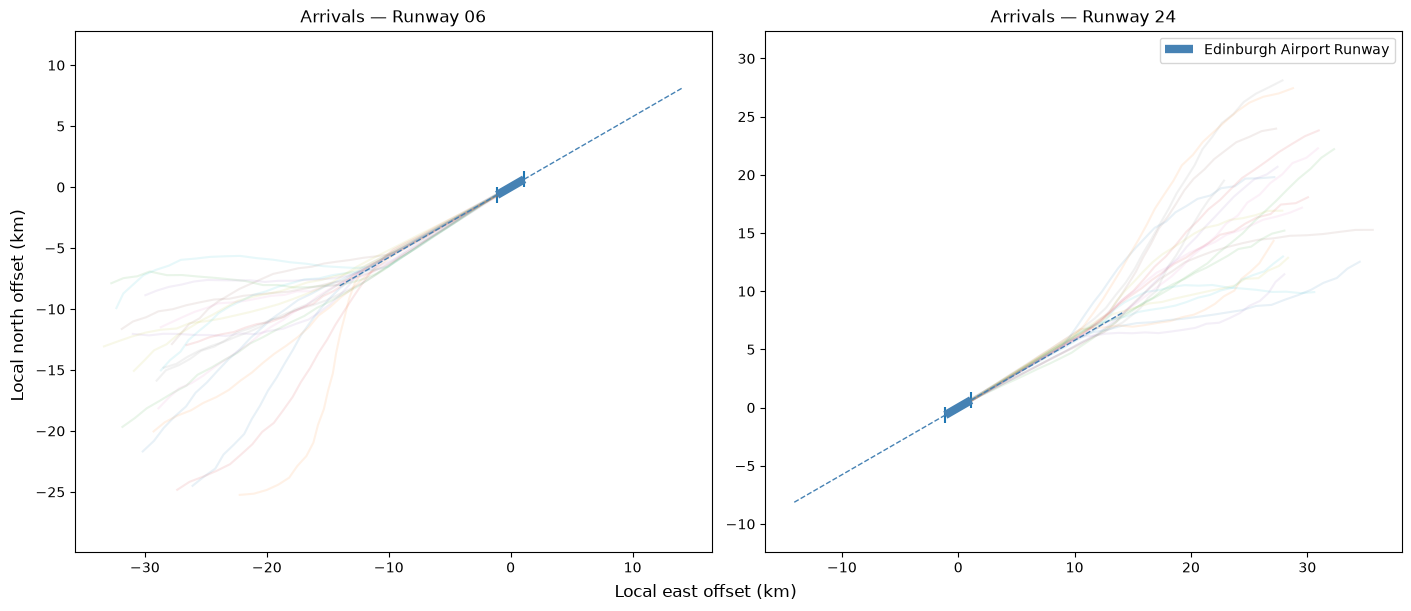

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, (runway_value, label) in zip(
    axes,
    [(0, "06"), (1, "24")],
):
    for traj in trajectories[runway == runway_value][20:40]:
        ax.plot(traj[:, 0], traj[:, 1], alpha=0.10)

    draw_edinburgh_runway(ax=ax, show_extended_final=True)
    ax.set_title(f"Arrivals — Runway {label}")
    ax.set_xlim(*AIRSPACE_XLIM)
    ax.set_ylim(*AIRSPACE_YLIM)
    ax.axis("equal")

ax.legend()
fig.supxlabel("Local east offset (km)")
fig.supylabel("Local north offset (km)")
plt.show()

## 2. Flatten and standardise

The $(x_1​,y_1​), (x_2​,y_2​),\ldots, (x_{30}​,y_{30}​),$ waypoint pairs become one $60$-dimensional vector, $(x_1​,y_1​,x_2​,y_2​,\ldots,x_{30}​,y_{30}​)$.

Standardisation statistics are estimated from the training set only and stored for later inversion.


In [4]:
flat = trajectories.reshape(len(trajectories), -1)

DIMENSION = flat.shape[1]

n = len(flat)
perm = torch.randperm(n, generator=torch.Generator().manual_seed(SEED))

n_train = int(0.80 * n)
n_val = int(0.10 * n)

idx_train = perm[:n_train]
idx_val = perm[n_train:n_train + n_val]
idx_test = perm[n_train + n_val:]

x_train_raw = flat[idx_train]
c_train = runway[idx_train]

x_val_raw = flat[idx_val]
c_val = runway[idx_val]

x_test_raw = flat[idx_test]
c_test = runway[idx_test]

train_mean = x_train_raw.mean(dim=0)
train_std = x_train_raw.std(dim=0).clamp_min(0.05)

def standardise(x):
    return (x - train_mean) / train_std

def unstandardise(x):
    return x * train_std + train_mean

#Standardise as the base distribution for normalising flow is standard Gaussian
x_train = standardise(x_train_raw)
x_val = standardise(x_val_raw)
x_test = standardise(x_test_raw)

BATCH_SIZE = 128

train_loader = DataLoader(TensorDataset(x_train, c_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, c_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(x_test, c_test), batch_size=BATCH_SIZE, shuffle=False)

print("Flow dimension:", DIMENSION)
print("Train/validation/test:", len(x_train), len(x_val), len(x_test))

Flow dimension: 60
Train/validation/test: 3200 400 400


## 3. Conditional affine coupling

A normalising flow builds a flexible transformation by composing several simple invertible layers,

$$
f_\theta=f_K\circ\cdots\circ f_1.
$$

Each layer uses a binary mask to split the trajectory vector into two parts. One part, $\mathbf{x}_A$, is kept fixed, while the other part, $\mathbf{x}_B$, is transformed as

$$
\mathbf{y}_A=\mathbf{x}_A, \qquad
\mathbf{y}_B=\mathbf{x}_B\odot\exp\!\{\mathbf{s}(\mathbf{x}_A,\mathrm{RWY})\}+\mathbf{\tau}(\mathbf{x}_A, \mathrm{RWY}).
$$
A small neural network learns the scale $\mathbf{s}$ and transition $\mathrm{\tau}$.

Different layers use different masks, so that all coordinates can eventually influence one another. In the implementation, the scale and transition are bounded for numerical stability and `SiLU` activations are used in the conditioner network.

Because one part of the input remains unchanged, the transformation can be inverted exactly and its Jacobian determinant is inexpensive to compute. These two properties make affine coupling layers convenient building blocks for normalising flows.

The complete transformation maps a trajectory $\mathbf{x}$ to a latent vector
$$
\mathbf{z}=f_\theta(\mathbf{x};\mathrm{RWY})=f_K\!\left(\cdots f_2(f_1(\mathbf{x};c);\mathrm{RWY})\right).
$$

> **Implementation details.** The precise masking scheme, bounded scale/transition parameterisation, inverse transformation and log-Jacobian calculation are given in the appendix.

In [5]:
def make_balanced_masks(
    dimension,
    n_layers,
    seed=SEED + 99,
):
    masks = []

    for _ in range((n_layers + 1) // 2):
        perm = torch.randperm(dimension, generator=torch.Generator().manual_seed(seed))
        mask = torch.zeros(dimension)
        mask[perm[: dimension // 2]] = 1.0 #assigns half the coordinates a value of 1.0 and the other half a value of 0.0, creating a binary mask for the affine coupling layer
        masks.append(mask)

        if len(masks) < n_layers:
            masks.append(1.0 - mask)

    return masks[:n_layers]


class ConditionalAffineCoupling(nn.Module): 
    def __init__(
        self,
        dimension, #input dimension, d=60
        mask,
        hidden_dim=128, #neural network hidden dimension
        condition_dim=2, #Runway labels
        scale_limit=1.2, #restricts the range of scaling factors to prevent extreme transformations
        shift_limit=3.0, #restricts the range of transition factors to prevent extreme transformations
    ):
        super().__init__()

        self.register_buffer("mask", mask.float()) #registering the splits of the two groups
        self.condition_dim = condition_dim
        self.scale_limit = float(scale_limit)
        self.shift_limit = float(shift_limit)

        self.net = nn.Sequential(
            nn.Linear(dimension + condition_dim, hidden_dim),
            nn.SiLU(), #Smooth nonlinear activation function
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2 * dimension))

        # Start close to the identity transformation.
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def _scale_shift(self, fixed_x, condition): #helper function to determine the affine transformation parameters
        context = F.one_hot(condition.long(), num_classes=self.condition_dim,).float() #one-hot encoding of the runway
        h = torch.cat([fixed_x, context], dim=1) #combine trajectory information and condition
        raw_scale, raw_shift = self.net(h).chunk(2, dim=1) #predicting raw scale and shift through the network output
        transformed = 1.0 - self.mask #identify coordinates to transform
        scale = (self.scale_limit* torch.tanh(raw_scale)* transformed)
        shift = (self.shift_limit* torch.tanh(raw_shift / self.shift_limit)* transformed)

        return scale, shift

    def forward(self, x, condition):
        fixed_x = x * self.mask
        scale, shift = self._scale_shift(fixed_x, condition)
        y = fixed_x + (1.0 - self.mask) * (x * torch.exp(scale) + shift)

        return y, scale.sum(dim=1)

    def inverse(self, y, condition):
        fixed_y = y * self.mask
        scale, shift = self._scale_shift(fixed_y, condition)
        x = fixed_y + (1.0 - self.mask) * ((y - shift) * torch.exp(-scale))

        return x, -scale.sum(dim=1)

## 4. Invertibility test before training

This is a unit test for the defining mathematical property of the flow.
Do not proceed if the round-trip error is not close to floating-point precision.


In [6]:
test_layer = ConditionalAffineCoupling(DIMENSION, make_balanced_masks(DIMENSION, 1)[0]).to(device)

probe_x = torch.randn(128, DIMENSION, device=device) #generating artificial test inputs
probe_c = torch.randint(0, 2, (128,), device=device) 

with torch.inference_mode():
    y, ld = test_layer(probe_x, probe_c) #applying forward transformation (f(x|RWY), log absolute jacobian determinant)
    x_back, ild = test_layer.inverse(y, probe_c) #inverse transformation

reconstruction_error = (probe_x - x_back).abs().max().item() 
logdet_error = (ld + ild).abs().max().item()

print("One-layer reconstruction error:", f"{reconstruction_error:.7f}")
print("One-layer log-det error:", f"{logdet_error:.7f}")


One-layer reconstruction error: 0.0000000
One-layer log-det error: 0.0000000


## 5. Stack coupling layers into a conditional Real NVP Normalising Flow

A single affine coupling layer only transforms part of the trajectory vector. To obtain a more flexible model, we compose several coupling layers,

$$
f_\theta=f_K\circ f_{K-1}\circ\cdots\circ f_1,
$$

giving the conditional transformation $\mathbf{z}=f_\theta(\mathbf{x}\mid\mathrm{RWY})$.

We use $K=12$ coupling layers with fixed masks arranged in complementary pairs. If one layer keeps a coordinate fixed, the next layer transforms it, so every coordinate is updated once within each pair.

The masks randomly mix coordinates from different waypoints rather than repeatedly using the simple even/odd split

$$
(x_1,x_2,\ldots)\qquad\text{versus}\qquad(y_1,y_2,\ldots).
$$

Stacking the layers therefore allows increasingly complex dependencies between the coordinates of the complete trajectory while preserving exact invertibility.


In [8]:
class EdinburghArrivalRealNVP(nn.Module):
    def __init__(
        self,
        dimension=DIMENSION,
        n_layers=8,
        hidden_dim=64,
        condition_dim=2,
        scale_limit=1.2,
        shift_limit=3.0,
    ):
        super().__init__()
        self.config = {
            "dimension": dimension,
            "n_layers": n_layers,
            "hidden_dim": hidden_dim,
            "condition_dim": condition_dim,
            "scale_limit": scale_limit,
            "shift_limit": shift_limit,
        }
        masks = make_balanced_masks(dimension,n_layers) #Generate mask for all 8 layers

        self.layers = nn.ModuleList([
            ConditionalAffineCoupling(
                dimension=dimension,
                mask=mask,
                hidden_dim=hidden_dim,
                condition_dim=condition_dim,
                scale_limit=scale_limit,
                shift_limit=shift_limit,
            )
            for mask in masks
        ])

    def forward(self, x, condition): #Applying to all coupling layers
        z = x
        total_logdet = torch.zeros(len(x), device=x.device)

        for layer in self.layers:
            z, logdet = layer(z, condition)
            total_logdet += logdet

        return z, total_logdet

    def inverse(self, z, condition): #Applying to all coupling layers
        x = z
        total_inverse_logdet = torch.zeros(len(z), device=z.device)

        for layer in reversed(self.layers):
            x, logdet = layer.inverse(x, condition)
            total_inverse_logdet += logdet

        return x, total_inverse_logdet


LOG_2PI = math.log(2.0 * math.pi)

def standard_normal_log_prob(z):
    return -0.5 * (z.pow(2) + LOG_2PI).sum(dim=1)

def flow_log_prob(model, x, condition):
    z, logdet = model(x, condition)
    return (standard_normal_log_prob(z) + logdet)

def flow_nll(model, x, condition):
    return -flow_log_prob(model, x, condition).mean()


flow = EdinburghArrivalRealNVP().to(device)
probe_x = torch.randn(128, DIMENSION, device=device) #sanity check
probe_c = torch.randint(0, 2, (128,), device=device)

with torch.inference_mode():
    z, ld = flow(probe_x, probe_c)
    x_back, ild = flow.inverse(z, probe_c)

roundtrip = (probe_x - x_back).abs().max().item()
logdet_consistency = (ld + ild).abs().max().item()

print("Full-flow round-trip:", f"{roundtrip:.2e}")
print("Full-flow log-det error:", f"{logdet_consistency:.2e}")
print("Trainable parameters:", f"{sum(p.numel() for p in flow.parameters()):,}")

Full-flow round-trip: 0.00e+00
Full-flow log-det error: 0.00e+00
Trainable parameters: 127,936


## 6. Exact log-likelihood by change of variables

For a trajectory x and runway c,

$$
\log p(x \mid \mathrm{RWY})=\log p_Z\{f(x, \mathrm{RWY})\}
+\log |\det J_f(x,\mathrm{RWY})|.$$

The base density is a 32-dimensional standard Gaussian.

Validation and test NLL are evaluated on the test trajectories. We also train longer, reduce the learning rate when validation stalls, and restore the best validation checkpoint.


Best epoch at 93 with best validation NLL -188.486
Post-training reconstruction error: 1.43e-06
Post-training log-det error: 6.10e-05


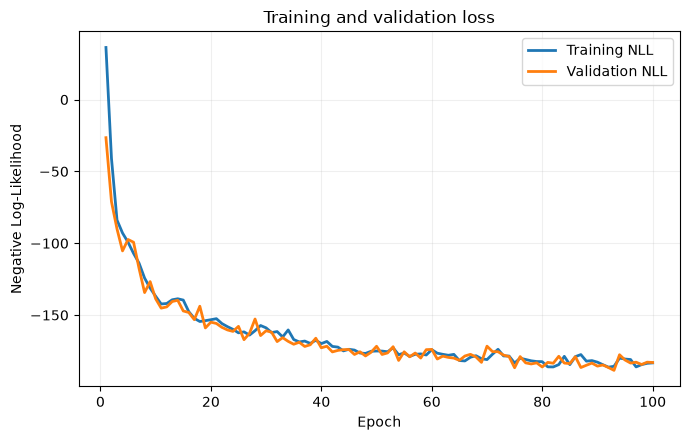

In [9]:
def evaluate_flow_nll(model, loader):
    model.eval()

    total = 0.0
    count = 0

    with torch.inference_mode():
        for x, condition in loader:
            x = x.to(device)
            condition = condition.to(device)
            log_prob = flow_log_prob(model, x, condition) #evaluate the trajectory log probability

            total += (-log_prob).sum().item()
            count += len(x)

    return total / count

optimizer = torch.optim.AdamW(
    flow.parameters(),
    lr=1e-2,
    weight_decay=5e-4)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode="min",
#     factor=0.5,
#     patience=7,
#     min_lr=5e-5,
# )

N_EPOCHS = 100

history = {
    "train_nll": [],
    "val_nll": [],
}

best_val_nll = float("inf")
best_epoch = None
best_state = None

fig, ax = plt.subplots(figsize=(7, 4.5))
for epoch in range(1, N_EPOCHS + 1):
    flow.train()

    total = 0.0
    count = 0

    for x, condition in train_loader: #looping over mini batches
        x = x.to(device)
        condition = condition.to(device)

        optimizer.zero_grad()

        loss = flow_nll(flow, x, condition)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)

        optimizer.step()

        total += loss.item() * len(x)
        count += len(x)

    train_nll = total / count
    val_nll = evaluate_flow_nll(flow, val_loader)

    history["train_nll"].append(train_nll)
    history["val_nll"].append(val_nll)

    if val_nll < best_val_nll: #detect best validation model
        best_val_nll = val_nll
        best_epoch = epoch

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in flow.state_dict().items()
        }

    epochs = range(1, epoch + 1)
    ax.clear()
    ax.plot(
        epochs,
        history["train_nll"],
        label="Training NLL",
        linewidth=2,
    )

    ax.plot(
        epochs,
        history["val_nll"],
        label="Validation NLL",
        linewidth=2,
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Negative Log-Likelihood")
    ax.set_title("Training and validation loss")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    clear_output(wait=True)
    display(fig)

    print(
        f"Epoch {epoch:02d}/{N_EPOCHS} | "
        f"train loss {train_nll:.3f} | "
        f"val loss {val_nll:.3f}"
    )
clear_output(wait=True)
flow.load_state_dict(best_state)
print(f"Best epoch at {best_epoch}", f"with best validation NLL {best_val_nll:.3f}")

x_probe = x_test[:128].to(device)
c_probe = c_test[:128].to(device)

with torch.inference_mode():
    z_probe, ld = flow(x_probe, c_probe)
    x_back, ild = flow.inverse(z_probe, c_probe)

post_roundtrip = (x_probe - x_back).abs().max().item()
post_logdet = (ld + ild).abs().max().item()

print("Post-training reconstruction error:", f"{post_roundtrip:.2e}")
print("Post-training log-det error:", f"{post_logdet:.2e}")

## 7. Conditional Gaussian baseline

A full-covariance Gaussian for each runway is meaningful because it captures the mean arrival shape, marginal variability at every waypoint and linear dependence among all 32 coordinates.

We compare the conditional Normalising flow model against a full-covariance Gaussian fitted separately for each runway. Both models are evaluated using average negative log-likelihood on the same held-out test trajectories. A lower test NLL indicates that the model assigns greater probability density to unseen trajectories.

In [10]:
def empirical_covariance(x):
    centred = x - x.mean(dim=0, keepdim=True)
    return centred.T @ centred / (len(x) - 1)

gaussian_models = {}

for condition in [0, 1]:
    xc = x_train[c_train == condition]
    mean = xc.mean(dim=0)
    covariance = empirical_covariance(xc)
    covariance += 2e-3 * torch.eye(DIMENSION)

    gaussian_models[condition] = torch.distributions.MultivariateNormal(mean, covariance_matrix=covariance)

def conditional_gaussian_nll(x, c):
    log_prob = torch.empty(len(x))

    for condition in [0, 1]:
        mask = c == condition
        if mask.any():
            log_prob[mask] = gaussian_models[condition].log_prob(x[mask])

    return -log_prob.mean().item()

gaussian_test_nll = conditional_gaussian_nll(x_test, c_test)
flow_test_nll = evaluate_flow_nll(flow, test_loader)

print("Conditional Gaussian test NLL:", round(gaussian_test_nll, 3))
print("Normalising-Flow test NLL:", round(flow_test_nll, 3))

Conditional Gaussian test NLL: -115.405
Normalising-Flow test NLL: -188.041


## 8. Generate continuous Edinburgh arrivals

Sampling is: $z \sim \mathrm{N}(\mathbf{0},\mathbf{I})$

→ inverse flow conditioned on runway

→ undo standardisation

→ reshape into 30 `(East, North)` waypoints.

There is no spatial quantisation and no sequential token sampling.


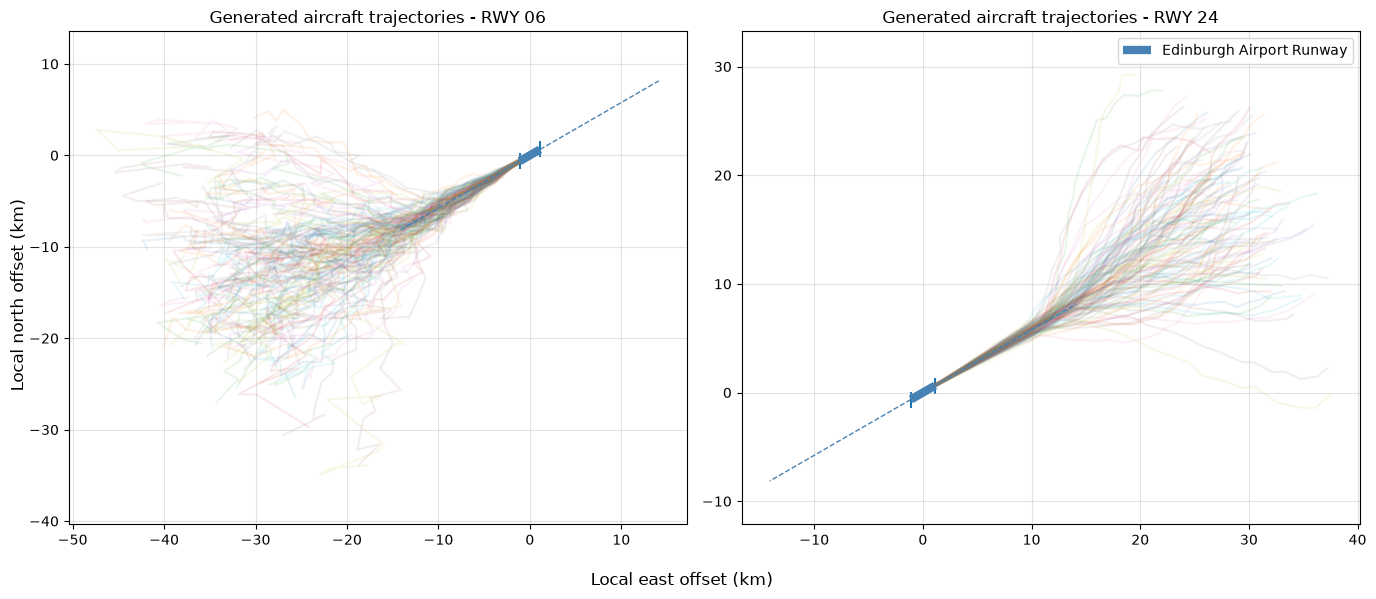

In [11]:
def sample_trajectories(
    model,
    n_samples,
    runway,
    seed = 20260908,
):
    model.eval()
    g = torch.Generator().manual_seed(seed)
    z = torch.randn( n_samples, DIMENSION, generator=g).to(device)
    condition = torch.full((n_samples,), runway, dtype=torch.long, device=device)

    with torch.inference_mode():
        x_standardised, _ = model.inverse(z, condition)

    x = unstandardise(x_standardised.cpu())
    return x.reshape(n_samples, N_WAYPOINTS, 2)

generated_06 = sample_trajectories(flow, 400, runway=0)
generated_24 = sample_trajectories(flow, 400, runway=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, generated, label in zip(
    axes,
    [generated_06, generated_24],
    ["06", "24"],
):
    for traj in generated[:120]:
        ax.plot(traj[:, 0], traj[:, 1], alpha=0.10)

    draw_edinburgh_runway(ax=ax, show_extended_final=True)
    ax.set_title(f"Generated aircraft trajectories - RWY {label}")
    ax.axis("equal")
    ax.grid(which="major", linewidth=0.8, alpha=0.35)
    ax.grid(which="minor", linewidth=0.4, alpha=0.15)


fig.supxlabel("Local east offset (km)")
fig.supylabel("Local north offset (km)")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Geometric diagnostic: step length

A model can generate trajectories that look plausible overall while still making unrealistic movements between neighbouring waypoints.

For consecutive waypoints

$$
\mathbf{x}_t=(x_t,y_t), \qquad \mathbf{x}_{t+1}=(x_{t+1},y_{t+1}),
$$

we compute the Euclidean step length

$$
d_t=\|\mathbf{x}_{t+1}-\mathbf{x}_t\|_2=\sqrt{(x_{t+1}-x_t)^2+(y_{t+1}-y_t)^2}.
$$

For each runway, we compare the distribution of these distances for generated trajectories against the corresponding held-out observed trajectories.

A close match suggests that the generated paths reproduce the local waypoint-to-waypoint geometry of the observed flights.


RWY 06 average waypoint spacing: Observed: 1.182 km | Generated: 1.701 km | Coverage: 88.7%
RWY 24 average waypoint spacing: Observed: 1.189 km | Generated: 1.217 km | Coverage: 99.8%


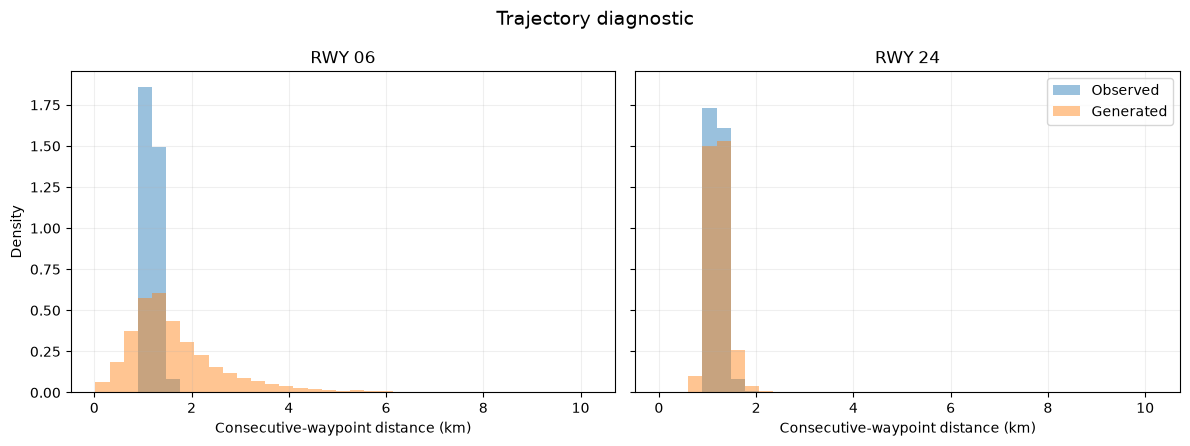

In [12]:
def step_lengths(xy):
    return torch.linalg.vector_norm(xy[:, 1:, :] - xy[:, :-1, :], dim=-1)

def fraction_inside_plot_airspace(xy):
    inside = (
        (xy[:, :, 0] >= AIRSPACE_XLIM[0])
        & (xy[:, :, 0] <= AIRSPACE_XLIM[1])
        & (xy[:, :, 1] >= AIRSPACE_YLIM[0])
        & (xy[:, :, 1] <= AIRSPACE_YLIM[1])
    )

    return inside.all(dim=1).float().mean()

# Convert held-out test data back to physical trajectory coordinates
x_test_physical = x_test * train_std + train_mean
x_test_xy = x_test_physical.reshape(-1, N_WAYPOINTS, 2)

# Separate by runway
observed_06 = x_test_xy[c_test == 0]
observed_24 = x_test_xy[c_test == 1]
# Step-length distributions
obs_steps_06 = step_lengths(observed_06).flatten()
gen_steps_06 = step_lengths(generated_06).flatten()
obs_steps_24 = step_lengths(observed_24).flatten()
gen_steps_24 = step_lengths(generated_24).flatten()


# Summary statistics
print(
    "RWY 06 average waypoint spacing: "
    f"Observed: {obs_steps_06.mean().item():.3f} km | "
    f"Generated: {gen_steps_06.mean().item():.3f} km | "
    f"Coverage: "
    f"{100 * fraction_inside_plot_airspace(generated_06).item():.1f}%"
)

print(
    "RWY 24 average waypoint spacing: "
    f"Observed: {obs_steps_24.mean().item():.3f} km | "
    f"Generated: {gen_steps_24.mean().item():.3f} km | "
    f"Coverage: "
    f"{100 * fraction_inside_plot_airspace(generated_24).item():.1f}%"
)

# Use common bins so the two runway panels are directly comparable
all_steps = torch.cat([obs_steps_06, gen_steps_06, obs_steps_24, gen_steps_24])
bins = torch.linspace(all_steps.min(), all_steps.max(), 36).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

for ax, obs_steps, gen_steps, runway in [
    (axes[0], obs_steps_06, gen_steps_06, "06"),
    (axes[1], obs_steps_24, gen_steps_24, "24"),
]:
    ax.hist(obs_steps.numpy(), bins=bins, density=True, alpha=0.45, label="Observed")
    ax.hist(gen_steps.numpy(), bins=bins, density=True, alpha=0.45, label="Generated")
    ax.set_title(f"RWY {runway}")
    ax.set_xlabel("Consecutive-waypoint distance (km)")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Density")
axes[1].legend()
fig.suptitle("Trajectory diagnostic", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Same latent draw, different runway condition

To inspect the effect of conditioning, we take one latent vector

$$
\mathbf{z}\in\mathbb{R}^{60}
$$

and decode it twice using the same trained flow:

$$
\mathbf{x}_{06}=f_\theta^{-1}(\mathbf{z}\mid\mathrm{RWY}=0),\qquad\mathbf{x}_{24}=f_\theta^{-1}(\mathbf{z}\mid\mathrm{RWY}=1).
$$

Each decoded vector corresponds to a complete 30-waypoint trajectory.

Because the latent input $\mathbf{z}$ is held fixed, any difference between the two generated trajectories is due to changing the runway condition supplied to the model.

This is a **model-inspection exercise** showing how the conditional flow responds to the runway label; it is not a causal statement about how a real aircraft would behave under a different runway assignment.


Latent input z:
tensor([ 0.6855, -1.2433,  0.6503,  1.7461, -1.5691, -1.0888, -0.2956,  0.0582,
        -1.5052,  1.0458,  0.3358, -0.8030, -1.0766, -0.5173, -0.4558,  0.0994,
        -0.1943, -0.9160,  1.0662, -1.0030, -1.2724,  0.6824, -1.1222, -2.3492,
         0.3874,  0.4780,  1.0780,  1.8935, -0.4513, -0.5255, -0.0691,  0.8249,
        -0.4882,  0.3180, -0.6617,  0.7154, -1.0585,  1.5954,  0.3898,  0.8361,
        -0.2756, -0.0453, -0.1053, -0.0337, -0.2067, -0.0089,  2.3037, -0.3902,
        -1.2070,  0.2212,  2.3484,  0.3140, -0.7834,  0.1515, -0.6635,  0.1524,
         0.5320, -0.3980,  1.4784,  0.6966])


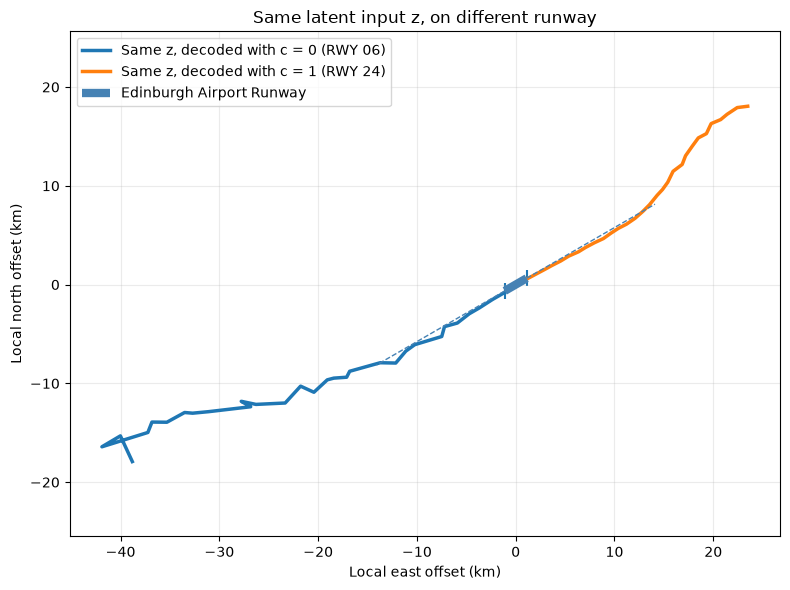

In [14]:
paired_generator = torch.Generator().manual_seed(7777)
N_SAMPLES = 6
paired_z = torch.randn(N_SAMPLES, DIMENSION, generator=paired_generator).to(device)
condition_06 = torch.zeros(N_SAMPLES, dtype=torch.long, device=device)
condition_24 = torch.ones(N_SAMPLES, dtype=torch.long, device=device)

# Use the same latent vector for both runway conditions
z_used = paired_z[0]

print("Latent input z:")
print(z_used.cpu())


with torch.inference_mode():
    x06_std, _ = flow.inverse(paired_z, condition_06)
    x24_std, _ = flow.inverse(paired_z, condition_24)

x06 = unstandardise(x06_std.cpu()).reshape(N_SAMPLES, N_WAYPOINTS, 2)
x24 = unstandardise(x24_std.cpu()).reshape(N_SAMPLES, N_WAYPOINTS, 2)


# Plot the first latent vector decoded under both conditions
plt.figure(figsize=(8, 6))

plt.plot(
    x06[0, :, 0],
    x06[0, :, 1],
    linewidth=2.5,
    label="Same z, decoded with c = 0 (RWY 06)",
)

plt.plot(
    x24[0, :, 0],
    x24[0, :, 1],
    linewidth=2.5,
    label="Same z, decoded with c = 1 (RWY 24)",
)

draw_edinburgh_runway(show_extended_final=True)

plt.xlabel("Local east offset (km)")
plt.ylabel("Local north offset (km)")
plt.title("Same latent input z, on different runway")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Save the flow and preprocessing

The standardisation statistics are required to interpret generated coordinates in kilometres, so they are stored alongside the neural-network weights.


In [13]:
checkpoint_path = Path("edinburgh_arrival_nf.pt")

checkpoint = {
    "model_state_dict": flow.state_dict(),
    # Architecture is taken directly from the trained model
    "model_config": flow.config,
    # Preprocessing information
    "train_mean": train_mean,
    "train_std": train_std,
    "n_waypoints": N_WAYPOINTS,
    # Meaning of the condition variable
    "condition_labels": {
        0: "Edinburgh Runway 06",
        1: "Edinburgh Runway 24",
    },
}

torch.save(checkpoint, checkpoint_path)

loaded = torch.load(checkpoint_path, map_location=device, weights_only=False)
reloaded = EdinburghArrivalRealNVP(**loaded["model_config"]).to(device)
reloaded.load_state_dict(loaded["model_state_dict"])
reloaded.eval()

with torch.inference_mode():
    z_a, ld_a = flow(x_test[:4].to(device), c_test[:4].to(device))
    z_b, ld_b = reloaded(x_test[:4].to(device), c_test[:4].to(device))

print("Max latent difference:", (z_a - z_b).abs().max().item())
print("Max log-det difference:", (ld_a - ld_b).abs().max().item())

Max latent difference: 0.0
Max log-det difference: 0.0


### Why the first affine flow struggled

This synthetic dataset is visually simple but statistically difficult for a small exact-density model: the 60 coordinates are extremely correlated and lie close to a thin manifold.

- The full-covariance Gaussian is therefore a strong baseline because it captures the dominant linear dependence directly.
- With flattened ordering $(x₁,y₁,x₂,y₂,...)$, the original even/odd masks are effectively an **East-versus-North split**, so six layers provide limited mixing.
- With six layers and `scale_limit = 1.2`, each coordinate is directly rescaled only three times. That is not enough for some very low-variance directions.
- Pure maximum likelihood can over-squeeze an almost singular dataset. A model can obtain a better NLL but have an unstable inverse map and poor samples.

The diagnostic below quantifies how concentrated the condition-wise covariance is.

In [14]:
def covariance_spectrum(x):
    centred = x - x.mean(dim=0, keepdim=True)
    covariance = centred.T @ centred / (len(x) - 1)
    return torch.linalg.eigvalsh(covariance)

for condition, label in [(0, "06"), (1, "24")]:
    xc = x_train[c_train == condition]
    eigvals = covariance_spectrum(xc)

    print(
        f"RWY {label}: {len(xc)} training flights | "
        f"eigenvalues > 1e-4: {(eigvals > 1e-4).sum().item():2d}/{DIMENSION} | "
        f"largest eigenvalue: {eigvals.max().item():.3f}"
    )

RWY 06: 485 training flights | eigenvalues > 1e-4:  9/60 | largest eigenvalue: 1.950
RWY 24: 2715 training flights | eigenvalues > 1e-4:  9/60 | largest eigenvalue: 2.081


### Appendix: affine coupling implementation details

For layer $k$, let $\mathbf{m}_k\in\{0,1\}^d$ denote the binary mask. The fixed part is

$$
\mathbf{x}_A=\mathbf{m}_k\odot\mathbf{x}.
$$

The conditioner receives the fixed coordinates together with a one-hot encoding of the runway condition:

$$
(\widetilde{\mathbf{s}},\widetilde{\mathbf{\tau}})=g_k([\mathbf{x}_A,\mathbf{e}_\mathrm{RWY}]).
$$

The implementation bounds the scale and shift as

$$
\mathbf{s}=(1-\mathbf{m}_k)\odot s_{\max}\tanh(\widetilde{\mathbf{s}}), \quad
\mathbf{\tau}=(1-\mathbf{m}_k)\odot \tau_{\max}\tanh\!\left(\frac{\widetilde{\mathbf{\tau}}}{\tau_{\max}}\right).
$$

The forward transformation is

$$
\mathbf{y}=\mathbf{x}_A+(1-\mathbf{m}_k)\odot\left[\mathbf{x}\odot e^{\mathbf{s}}+\mathbf{\tau}\right].
$$

Since the masked coordinates are unchanged, the transformation can be inverted analytically:

$$
\mathbf{x}=\mathbf{y}_A+(1-\mathbf{m}_k)\odot\left[(\mathbf{y}-\mathbf{\tau})\odot e^{-\mathbf{s}}\right].
$$

The log-Jacobian determinant is

$$
\log\left|\det\frac{\partial\mathbf{y}}{\partial\mathbf{x}}\right|=\sum_j s_j.
$$

The masks are generated in complementary pairs, so coordinates fixed in one layer are transformed in the next. The final layer of the conditioner network is initialized to zero, giving

$$
\mathbf{s}=\mathbf{0},\qquad\mathbf{\tau}=\mathbf{0},
$$

so each coupling layer initially behaves as the identity map.
